In [1]:
import numpy as np
import qiskit.quantum_info as qi
from processtensor import QTensor, QuantumState, UnitarySE, ProcessTensor
from qiskit.visualization import plot_state_city, plot_state_hinton

# Test multi-time twirl

In [2]:
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])

pauli_list = [I, X, Y, Z]
pauli_tensor = np.array(pauli_list)

pauli_superops = [np.kron(p.conj(), p) for p in pauli_list]
pauli_superop_tensor = np.array(pauli_superops)

In [3]:
def pauli2_pt_choi(pt_choi):
    """"""
    n_qubits = int(np.log2(pt_choi.shape[0]) / 2)  # Number of system qubits
    twirled = np.zeros_like(pt_choi, dtype=np.complex128)
    factor = 1 / (4 ** n_qubits)  # Normalization factor for
    
    basis_strings = qi.pauli_basis(n_qubits)
    basis_superop_products = [superop_from_pauli_string(basis_string) for basis_string in basis_strings]
    
    for superop_product in basis_superop_products:
        
        twirled += factor * superop_product @ pt_choi @ superop_product.conj().T
        
    return twirled

def superop_from_pauli_string(pauli_string):
    n_qubits = len(pauli_string)
    
    superops = []
    
    for i in range(n_qubits):
        matrix = pauli_string[i].to_matrix()
        superop = np.kron(matrix, np.conj(matrix.T))
        superops.append(superop)
        
    return multi_kron(superops)

def multi_kron(Ms):
    """Compute the tensor product of a list of matrices."""
    prod = Ms[0]
    for i in range(1, len(Ms)):
        prod = np.kron(prod, Ms[i])
    return prod

In [4]:
def twirl_unitary(U, dS, dE):
    """Not working as intended, don't use"""
    # dS must be a power of 2 since we're using Pauli basis on qubits
    n_qubits = np.log2(dS)
    if n_qubits != int(n_qubits) or n_qubits < 1:
        raise ValueError("dS must be a power of 2.")
    else:
        n_qubits = int(n_qubits)

    pauli_ops = [p.to_matrix() for p in qi.pauli_basis(n_qubits)]
    env_op = np.eye(dE)
    twirl_ops = [np.kron(env_op, p) for p in pauli_ops]

    twirled = np.zeros_like(U, dtype=np.complex128)
    factor = 1 / (4 ** n_qubits)

    for t in twirl_ops:
        twirled += factor * t @ U @ t.conj().T

    return twirled * factor * 4

In [5]:
dS = 2
dE = 2
d = dS * dE

E_init = np.eye(dE)

rho = qi.random_density_matrix(dE).data
U1 = qi.random_unitary(d).data
U2 = qi.random_unitary(d).data
# U1 = np.eye(d)
# U2 = np.eye(d)

# q0 = QTensor(QuantumState.from_matrix(rho, dS=1))
# q1 = QTensor(UnitarySE.from_unitary(U1, dS, dE))
q0 = QuantumState.from_matrix(rho, dS=1)
q1 = UnitarySE.from_unitary(U1, dS, dE)
q2 = UnitarySE.from_unitary(U2, dS, dE)

pt = q1 @ q2
pt = ProcessTensor(pt.trace_subsystem(0, pt.ndim - 1))
choi_matrix = pt.choi_matrix
# choi_matrix = qi.random_density_matrix(dS**4).data

print(f"Process tensor is completely positive: {pt.is_cp()}")
print(f"QTensor dims: {pt.dims}")
print(f"Choi matrix dims: {choi_matrix.shape}")

# Apply MPO-style twirling that preserves bond dimension
twirled = pauli2_pt_choi(choi_matrix)
print(f"Twirled process tensor dims: {twirled.shape}")

Process tensor is completely positive: True
QTensor dims: (1, 4, 4, 4, 4, 1)
Choi matrix dims: (16, 16)
Twirled process tensor dims: (16, 16)


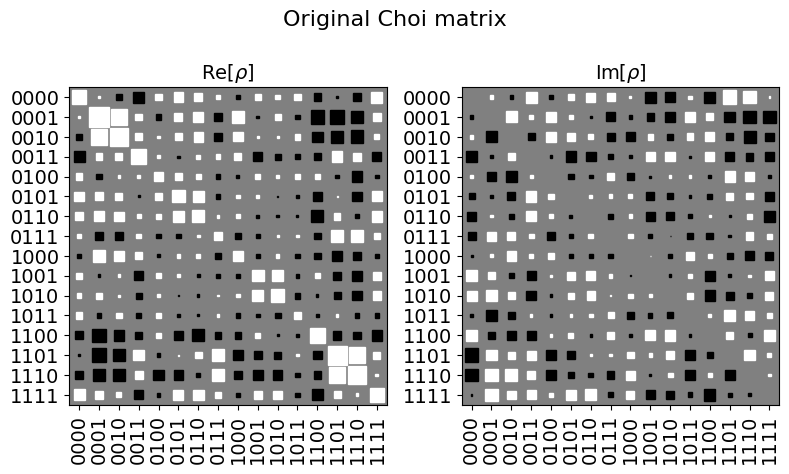

In [6]:
plot_state_hinton(choi_matrix, title="Original Choi matrix")

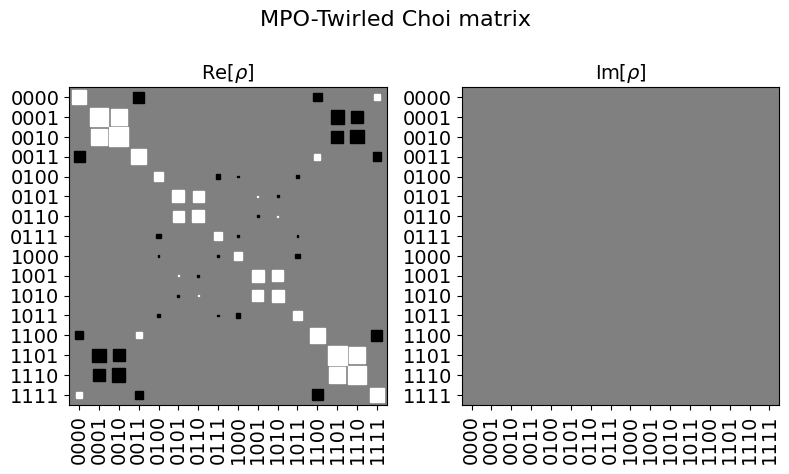

In [7]:
plot_state_hinton(twirled, title="MPO-Twirled Choi matrix")

In [8]:
def decompose_choi(choi_matrix):

    d = int(np.sqrt(choi_matrix.shape[0]))
    transposed = choi_matrix.reshape(d, d, d, d).transpose(0, 2, 1, 3).reshape(d**2, d**2)
    U, S, Vh = np.linalg.svd(transposed)
    n = np.sum(S > 1e-10)
    U = U[:, :n]
    S = S[:n]
    S_sqrt = np.sqrt(S)
    Vh = Vh[:n, :]
    
    U = U @ np.diag(S_sqrt)
    V = np.diag(S_sqrt) @ Vh

    return U, S, V

In [9]:
# Compare bond dimensions (rank of Choi matrices)
U1, S1, V1 = decompose_choi(choi_matrix)
n1 = np.sum(S1 > 1e-8)

U2, S2, V2 = decompose_choi(twirled)
n2 = np.sum(S2 > 1e-8)

print(f"=== Bond Dimension Comparison ===")
print(f"Original Choi matrix rank (bond dimension): {n1}")
print(f"MPO-twirled Choi matrix rank (bond dimension): {n2}")
print(f"Bond dimension preserved: {n1 == n2}")

print(f"\nOriginal singular values: {S1[S1 > 1e-10]}")
print(f"Twirled singular values: {S2[S2 > 1e-10]}")

=== Bond Dimension Comparison ===
Original Choi matrix rank (bond dimension): 4
MPO-twirled Choi matrix rank (bond dimension): 4
Bond dimension preserved: True

Original singular values: [3.48889025 2.7943543  0.86534589 0.75344095]
Twirled singular values: [3.02211405e+00 1.98212093e-01 8.50626305e-02 5.43856389e-04]


# Try Pauli twirling via einsum

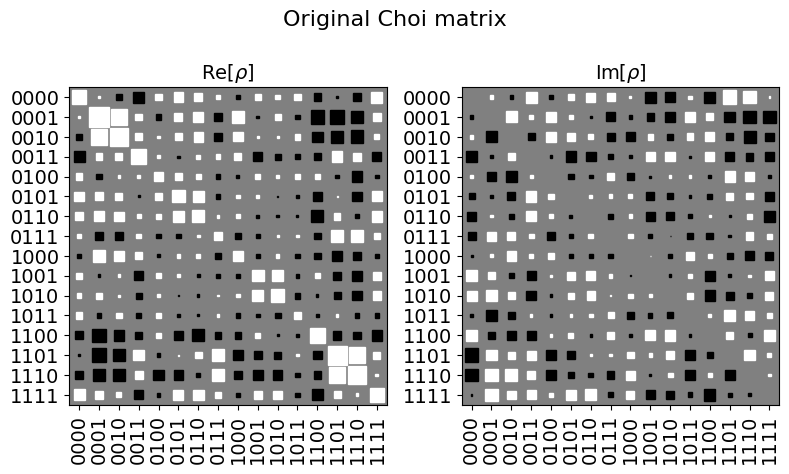

In [10]:
plot_state_hinton(pt.choi_matrix, title="Original Choi matrix")

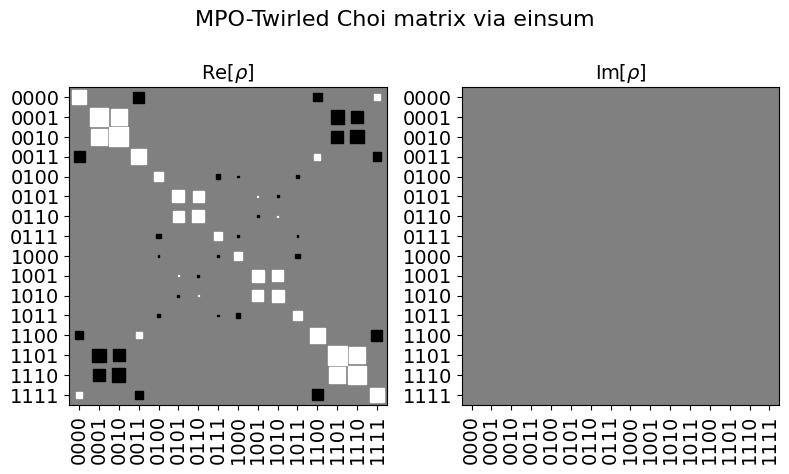

In [11]:
# Twirl the process tensor directly using einsum
twirled_tensor = np.einsum('abcd, xai, xbj, yck, ydl -> ijkl', pt.data.reshape(4, 4, 4, 4, order="F"), pauli_superop_tensor, pauli_superop_tensor, pauli_superop_tensor, pauli_superop_tensor)
twirled_tensor = twirled_tensor.reshape(1, 4, 4, 4, 4, 1, order="F")
pt_twirled_einsum = ProcessTensor(twirled_tensor)
plot_state_hinton(pt_twirled_einsum.choi_matrix, title="MPO-Twirled Choi matrix via einsum")

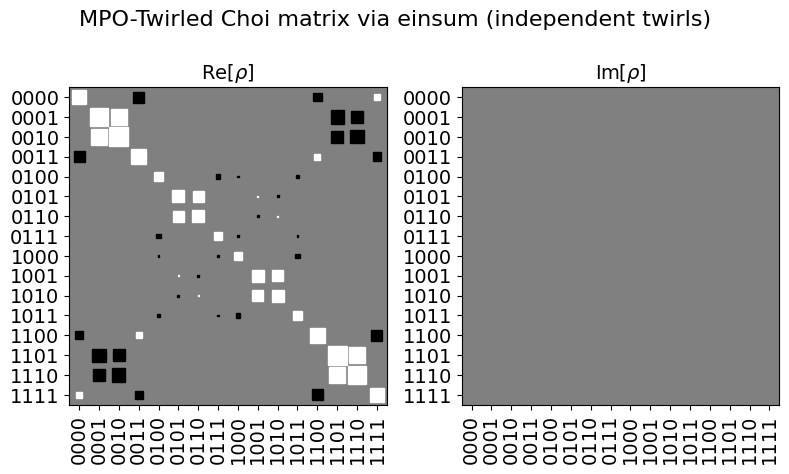

In [12]:
# Twirl the SE unitaries individually before composing them into a process tensor
q1_twirled = np.einsum('abcd, xbj, xck -> ajkd', q1.data, pauli_superop_tensor, pauli_superop_tensor)
q2_twirled = np.einsum('abcd, xbj, xck -> ajkd', q2.data, pauli_superop_tensor, pauli_superop_tensor)

q1_twirled = QTensor(q1_twirled)
q2_twirled = QTensor(q2_twirled)
q3 = q1_twirled @ q2_twirled
q3 = q3.trace_subsystem(0, q3.ndim - 1)

pt_twirled_einsum_ind = ProcessTensor(q3.reshape(1, 4, 4, 4, 4, 1, order="F"))

# I've confirmed that this matches the previous twirled result
plot_state_hinton(pt_twirled_einsum_ind.choi_matrix, title="MPO-Twirled Choi matrix via einsum (independent twirls)")

In [13]:
def unitary_svd(unitary, dS, dE):
    d = dS * dE
    U_tensor = np.reshape(unitary, (dE, dS, dE, dS), order="F")
    transposed = U_tensor.transpose(0, 2, 1, 3).reshape(dE**2, dS**2)
    U, S, Vh = np.linalg.svd(transposed)
    n = np.sum(S > 1e-10)
    U = U[:, :n]
    S = S[:n]
    Vh = Vh[:n, :]
    V = np.diag(S) @ Vh

    return U, S, V

def superop_svd(superop, dS, dE):
    shuffled = superop.transpose(0, 3, 1, 2).reshape(dE**4, dS**4)
    U, S, Vh = np.linalg.svd(shuffled)
    n = np.sum(S > 1e-10)
    U = U[:, :n]
    S = S[:n]
    Vh = Vh[:n, :]
    V = np.diag(S) @ Vh
    return U, S, V

In [14]:
dS = 2
dE = 2

unitary = qi.random_unitary(dS * dE).data
cnot = np.array([[1, 0, 0, 0],
                 [0, 1, 0, 0],
                 [0, 0, 0, 1],
                 [0, 0, 1, 0]])
swap = np.array([[1, 0, 0, 0],
                 [0, 0, 1, 0],
                 [0, 1, 0, 0],
                 [0, 0, 0, 1]])
unitary = swap

U0, S0, V0 = unitary_svd(unitary, dS, dE)
print(f"Unitary singular values: {S0}")
q1 = UnitarySE.from_unitary(unitary, dS, dE)

superop_twirled = np.einsum('abcd, xbj, xck -> ajkd', q1.data, pauli_superop_tensor, pauli_superop_tensor)
q2 = QTensor(superop_twirled)

U1, S1, V1 = superop_svd(q1.data, dS, dE)
U2, S2, V2 = superop_svd(q2.data, dS, dE)


Unitary singular values: [1. 1. 1. 1.]


In [15]:
len(S1)

16

In [16]:
len(S2)

4